# ECG Arrhythmia Detection — Testing Pipeline

**Course:** MSML612 Deep Learning
**Project:** Edge-Optimized Hybrid CNN-Transformer for Arrhythmia Detection

---

## What this notebook does

This notebook runs inference on the models trained in the Training Pipeline

## Why binary classification

The underlying MIT-BIH data supports the 5-class AAMI taxonomy (Normal, Supraventricular, Ventricular, Fusion, Unknown), but two problems show up when training on all 5 classes directly:

- **Severe class imbalance.** Fusion and Unknown beats each make up well under 1% of the dataset, so a model optimizing average loss has little incentive to learn them.
- **Window-level labeling collisions.** Each training window spans multiple beats, and is labeled by whichever AAMI class is most clinically significant within that window (worst-case labeling). A Ventricular beat occurring near a Supraventricular, Fusion, or Unknown beat causes the window to be labeled Ventricular, which starves the rarer classes of clean training signal.

Collapsing all four arrhythmia classes into a single **Abnormal** label sidesteps both problems, and matches the actual engineering use case: a wearable device doesn't need to name the arrhythmia, it needs to reliably flag *any* concerning rhythm for review.

## Why macro F1, not accuracy

The training set has meaningful class imbalance even after collapsing to binary labels (Normal windows outnumber Abnormal windows after augmentation). A model that leans toward predicting the majority class can post a high accuracy while missing many of the arrhythmias it exists to catch. **Macro F1** computes F1 independently for each class and averages the two, giving equal weight to catching Abnormal rhythms as to correctly labeling Normal ones — a more honest measure of clinical usefulness than raw accuracy.

## 1. Imports

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import importlib
import matplotlib.pyplot as plt
import tensorflow as tf
import tf_keras as keras
import tensorflow_model_optimization as tfmot
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import random

import model_builder

random.seed(69)
np.random.seed(69)
tf.keras.utils.set_random_seed(69)

## 2. Custom Macro F1 Metric

Keras does not include a built-in macro F1 metric, so it's implemented here as a custom `keras.metrics.Metric` subclass.

**How it works:**
- For each batch, it accumulates **true positives (TP)**, **false positives (FP)**, and **false negatives (FN)** per class using one-hot encodings — fully vectorized, no Python loops.
- At the end of each epoch, `result()` computes per-class F1 and returns their mean (macro average).
- `reset_state()` clears the accumulators before the next epoch.

This runs inside the Keras training loop, so `val_macro_f1` is available as an early stopping monitor and appears in the training history alongside loss and accuracy.

In [2]:
class MacroF1Score(keras.metrics.Metric):
    """
    Streaming macro F1-score for multi-class classification.
    Accumulates TP/FP/FN per class across batches, then averages F1 at epoch end.
    """

    def __init__(self, num_classes, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Per-class accumulators -- reset at the start of each epoch
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert predictions to hard class labels
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

        # One-hot encode both: (batch, num_classes)
        y_true_oh = tf.cast(tf.one_hot(y_true, self.num_classes), tf.float32)
        y_pred_oh = tf.cast(tf.one_hot(y_pred, self.num_classes), tf.float32)

        # Accumulate per-class TP, FP, FN
        self.tp.assign_add(tf.reduce_sum(y_true_oh * y_pred_oh,         axis=0))
        self.fp.assign_add(tf.reduce_sum((1 - y_true_oh) * y_pred_oh,   axis=0))
        self.fn.assign_add(tf.reduce_sum(y_true_oh * (1 - y_pred_oh),   axis=0))

    def result(self):
        # Per-class precision and recall, with epsilon to avoid division by zero
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall    = self.tp / (self.tp + self.fn + 1e-7)
        # Per-class F1
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        # Macro average: equal weight to both classes
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        self.tp.assign(tf.zeros(self.num_classes))
        self.fp.assign(tf.zeros(self.num_classes))
        self.fn.assign(tf.zeros(self.num_classes))

## 3. Data Loading, and Threshold

We performed some further Data processing in the Training Pipeline (collapsing the classes into Normal vs Abnormal) and that is being performed here.

We are also hardcoding the threshold values obtained in our Training Pipeline. These are based on the Validation performance, and should remain consistent.



In [3]:
#Load Test data and collapse classes into binary
SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, "processed")

X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

y_test = np.where(y_test > 0, 1, y_test)      
X_test = np.expand_dims(X_test, axis=-1)      

CLASS_NAMES_SHORT = ["Normal", "Abnormal"]


#Threshold values from Training Pipeline
threshold_orig   = 0.5289   
threshold_qat    = 0.4642   
THRESHOLD_TFLITE = 249.9849  

## 3. Model Loading

Code below loads the Standard and QAT models. Requires the original custom_objects_map to recreate. This is due to complications with QAT models.

In [4]:
#Custom objects map from model_builder.py

custom_objects_map = {
    'MultiHeadAttention': model_builder.MultiHeadAttention,
    'MultiHeadAttentionQAT': model_builder.MultiHeadAttentionQAT,
    'DotProductAttention': model_builder.DotProductAttention,
    'NoQuantizeConfig': model_builder.NoQuantizeConfig,
    'DepthwiseConv1DQAT': model_builder.DepthwiseConv1DQAT,
    'MacroF1Score': MacroF1Score,
}

#standard model loading
original_model = keras.models.load_model("original_model", custom_objects=custom_objects_map)


#the qat model is complicated. i can see now why researchers often don't put things on actual hardware
#our custom wrapped layers don't play nicely with being saved, so instead we just rebuild the qat model completely, and then give it the saved weights
qat_layer_model = model_builder.build_model(apply_qat=True)
qat_annotated_model = tfmot.quantization.keras.quantize_annotate_model(qat_layer_model)
with tfmot.quantization.keras.quantize_scope(custom_objects_map):
    qat_node_model = tfmot.quantization.keras.quantize_apply(qat_annotated_model)

# Load weights into the freshly-built (fully-built) architecture
qat_node_model.load_weights("qat_model_weights")


## 4. Standard and QAT model testing

Classification Code copied from our original Training Pipelie

In [5]:
# -- Get predictions using the calibrated thresholds -----------------------------
test_probs_orig = original_model.predict(X_test, verbose=0)[:, 1]
test_probs_qat  = qat_node_model.predict(X_test, verbose=0)[:, 1]

y_pred_orig = (test_probs_orig > threshold_orig).astype(int)
y_pred_qat  = (test_probs_qat  > threshold_qat).astype(int)

# -- Full classification report ---------------------------------------------------
print()
print("=" * 55)
print("STANDARD MODEL -- Classification Report (calibrated threshold)")
print("=" * 55)
print(classification_report(y_test, y_pred_orig, target_names=CLASS_NAMES_SHORT, digits=4))

print("=" * 55)
print("QAT MODEL -- Classification Report (calibrated threshold)")
print("=" * 55)
print(classification_report(y_test, y_pred_qat, target_names=CLASS_NAMES_SHORT, digits=4))


STANDARD MODEL -- Classification Report (calibrated threshold)
              precision    recall  f1-score   support

      Normal     0.8845    0.8984    0.8914     30005
    Abnormal     0.6674    0.6348    0.6507      9635

    accuracy                         0.8343     39640
   macro avg     0.7760    0.7666    0.7710     39640
weighted avg     0.8318    0.8343    0.8329     39640

QAT MODEL -- Classification Report (calibrated threshold)
              precision    recall  f1-score   support

      Normal     0.8955    0.8759    0.8856     30005
    Abnormal     0.6382    0.6818    0.6593      9635

    accuracy                         0.8287     39640
   macro avg     0.7669    0.7788    0.7724     39640
weighted avg     0.8330    0.8287    0.8306     39640



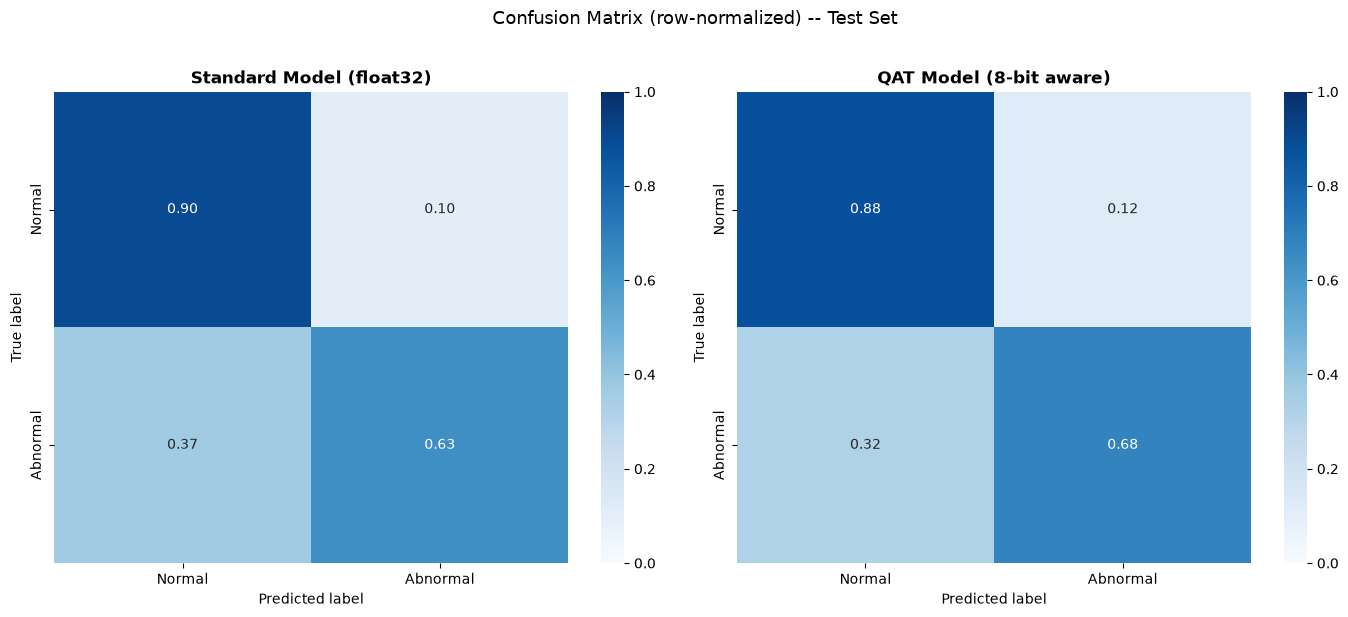

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_orig, y_pred_qat],
    ['Standard Model (float32)', 'QAT Model (8-bit aware)']
):
    cm = confusion_matrix(y_test, y_pred)
    # Normalize by true class counts for readability
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=CLASS_NAMES_SHORT,
        yticklabels=CLASS_NAMES_SHORT,
        ax=ax, vmin=0, vmax=1
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

plt.suptitle('Confusion Matrix (row-normalized) -- Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Int8 model testing

Classification Code copied from our original Training Pipelie

In [7]:
def evaluate_tflite_calibrated(tflite_path, X_test, y_test, best_threshold):

    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    in_scale, in_zp = input_details['quantization']

    preds = []
    for i in range(len(X_test)):
        sample = np.expand_dims(X_test[i], axis=0).astype(np.float32)
        sample = np.clip((sample / in_scale + in_zp).round(), -128, 127).astype(np.int8)

        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()

        result = interpreter.get_tensor(output_details['index'])[0].astype(np.float32)
        delta = result[1] - result[0]

        pred_class = 1 if delta > best_threshold else 0
        preds.append(pred_class)

    preds = np.array(preds)
    print(classification_report(y_test, preds, target_names=["Normal", "Abnormal"], digits=4))
    print("Macro F1:", f1_score(y_test, preds, average="macro"))
    print("Accuracy:", accuracy_score(y_test, preds))
    return preds

preds = evaluate_tflite_calibrated('model.tflite', X_test, y_test, THRESHOLD_TFLITE)

C:\Users\Thad\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


              precision    recall  f1-score   support

      Normal     0.8834    0.9297    0.9060     30005
    Abnormal     0.7385    0.6180    0.6729      9635

    accuracy                         0.8540     39640
   macro avg     0.8110    0.7739    0.7894     39640
weighted avg     0.8482    0.8540    0.8493     39640

Macro F1: 0.7894395971374553
Accuracy: 0.8539606458123108
